In [1]:
import numpy as np
import tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Layer 
from skimage import metrics

In [2]:
train_path = "mnist_png/training"
test_path = "mnist_png/testing"

IMG_SIZE = (28, 28)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=None,
    shuffle=False
)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [3]:
x_train = []
train_labels = []

for image, label in train_ds:
    x_train.append(image.numpy())
    train_labels.append(label.numpy())

x_train = np.array(x_train)
train_labels = np.array(train_labels)

x_test = []
test_labels = []

for image, label in test_ds:
    x_test.append(image.numpy())
    test_labels.append(label.numpy())

x_test = np.array(x_test)
test_labels = np.array(test_labels)

In [4]:
#Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [5]:
#Flattening
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [6]:
#Randomization
permutation = np.random.permutation(len(x_train))
x_train, train_labels = x_train[permutation], train_labels[permutation]
permutation = np.random.permutation(len(x_test))
x_test, test_labels = x_test[permutation], test_labels[permutation]

In [7]:
#Encoder
list_xtest = [ [x_test[i], test_labels[i]] for i in range(len(x_test))] 
print(len(list_xtest)) 

encoder_input = Input(shape=(784,))
encoded = Dense(64, activation='relu')(encoder_input)
encoder = Model(encoder_input, encoded)

10000


In [8]:
#Decoder
decoder_input = Input(shape=(64,))
decoded = Dense(784, activation='sigmoid')(decoder_input)
decoder = Model(decoder_input, decoded)

In [9]:
#Autoencoder
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)))

lr_schedule = tensorflow.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate = 5e-01, decay_steps = 2500, decay_rate = 0.75,staircase=True) 
tensorflow.keras.optimizers.Adam(learning_rate = lr_schedule,beta_1=0.95,beta_2=0.99,epsilon=1e-01)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

Epoch 1/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0813 - val_loss: 0.0463
Epoch 2/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0377 - val_loss: 0.0303
Epoch 3/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0266 - val_loss: 0.0228
Epoch 4/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0210 - val_loss: 0.0186
Epoch 5/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0174 - val_loss: 0.0155
Epoch 6/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0148 - val_loss: 0.0133
Epoch 7/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0128 - val_loss: 0.0115
Epoch 8/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111 - val_loss: 0.0101
Epoch 9/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0099 - val_loss: 0.0090
Epoch 10/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0089 - val_loss: 0.0081
Epoch 11/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0080 - val_loss: 0.0074
Epoch 12/25
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

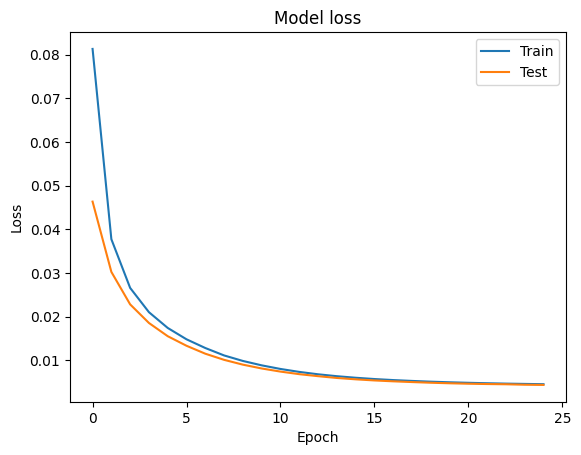

In [10]:
history = autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=512,
                shuffle=True,
                validation_data=(x_test, x_test))

# Plot the training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

In [11]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step


[np.int32(0), np.int32(4), np.int32(4), np.int32(6), np.int32(9), np.int32(7), np.int32(4), np.int32(4), np.int32(0), np.int32(9)]
Image 0: MSE = 0.010881, SSIM = 0.7926
Image 1: MSE = 0.012630, SSIM = 0.8001
Image 2: MSE = 0.004281, SSIM = 0.8306
Image 3: MSE = 0.004023, SSIM = 0.8891
Image 4: MSE = 0.003046, SSIM = 0.8744
Image 5: MSE = 0.002617, SSIM = 0.9176
Image 6: MSE = 0.005540, SSIM = 0.8603
Image 7: MSE = 0.002985, SSIM = 0.8723
Image 8: MSE = 0.002989, SSIM = 0.9127
Image 9: MSE = 0.005079, SSIM = 0.8564


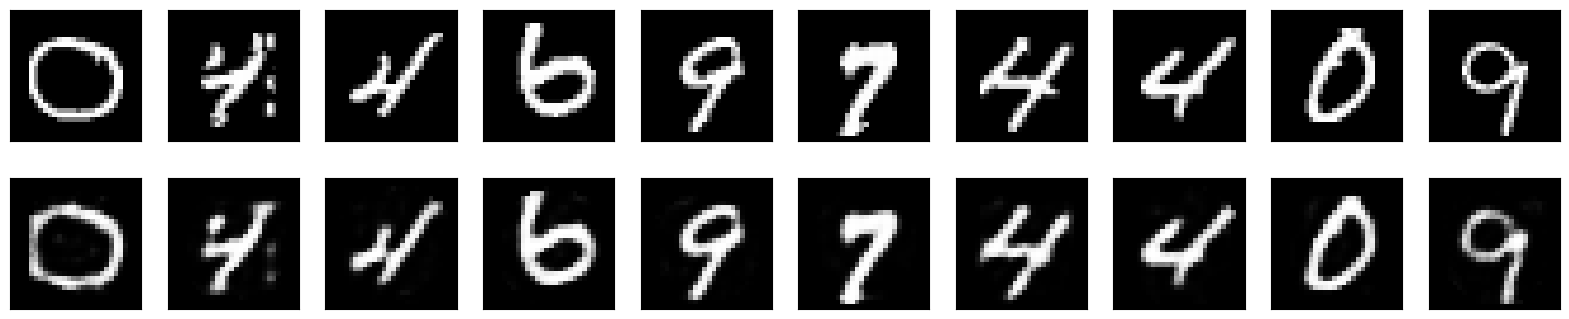

[np.int32(4), np.int32(6), np.int32(9), np.int32(7), np.int32(4), np.int32(4), np.int32(0), np.int32(9)]
[np.int32(6), np.int32(9), np.int32(7), np.int32(4), np.int32(4), np.int32(0), np.int32(9)]


In [12]:
def mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0])
    return err

def ssim(imageA, imageB):
    return metrics.structural_similarity(
        imageA,
        imageB,
        data_range=1.0,
        channel_axis=None
    )

decomser = [] 
decossimr = [] 
n = 10
list_xtestn = [ [x_test[i], test_labels[i]] for i in range(10)] 
print([list_xtestn[i][1] for i in range(n)]) 
plt.figure(figsize=(20, 4))
for i in range(n):
    # Orignal
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # After Decoding
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    msel = mse(list_xtestn[i][0], decoded_imgs[i])
    ssiml = ssim(list_xtestn[i][0], decoded_imgs[i])

    if msel <= 0.01:
        decomser.append(list_xtestn[i][1])

    if ssiml > 0.85:
        decossimr.append(list_xtestn[i][1])

    print(f"Image {i}: MSE = {msel:.6f}, SSIM = {ssiml:.4f}")
plt.show() 

print(decomser)
print(decossimr)